In [2]:
"""Test upward backscattering of rough surfaces"""
import sys
sys.path.append('../../../')
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import scipy.constants as sci_const
import matplotlib.pyplot as plt

from mores.interface.IEM_upward import Mue_upward_IEMs
from mores.interface.AIEM_upward import Mue_upward_AIEMs
from mores.interface.I2EM_upward import Mue_upward_I2EMs

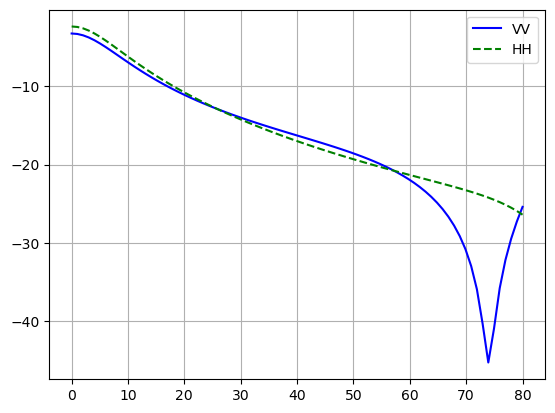

In [71]:
f = 1e9
kdel = 0.6
kcor = 3.0
epsr = 3.0 - 0.1j
c = sci_const.speed_of_light
Lambda = c / f
k = 2 * np.pi / Lambda

delta = kdel / k
corr_len = kcor / k

theta_is = np.linspace(0, 80, 80)

N = len(theta_is)
vvs = np.zeros(N)
hhs = np.zeros(N)
for i in range(N):
    theta_i = theta_is[i]
    theta_s = theta_i
    Mue = Mue_upward_I2EMs(f, (theta_s, 180), (theta_i, 10), epsr, delta, corr_len, spectrum='exp', x=1.5, shadow_flag=False)
    vvs[i] = 10*np.log10(4*np.pi * Mue[0, 0])
    hhs[i] = 10*np.log10(4*np.pi * Mue[1, 1])


# show
fig, ax = plt.subplots()
ax.plot(theta_is, vvs, 'b-', label='VV')
ax.plot(theta_is, hhs, 'g--', label='HH')
ax.grid()
# ax.set_ylim(-40, -10)
plt.legend()
plt.show()